# TAD Analysis with Age Correlation

Analysis of TAD border changes in relation to age and disease status.

In [60]:
import pandas as pd
import numpy as np
import bioframe as bf
import gseapy as gp
from gseapy import barplot, dotplot
import matplotlib.pyplot as plt


In [37]:
merged_bed = pd.read_pickle("./glia_tads_additional_files/merged_bed_with_tads_clustering_non_neurons.pickle")
len(set(merged_bed.source))

12

### 1. Identify diff borders

In [38]:
def get_list_of_up_down_borders(merged_bed, p_col = '_p_value', p_value_cutoff=0.05):
    modes = ['HC_vs_SZ']
    print(modes)
    assert len(modes) == 1
    mode = modes[0]
    
    print("____"*14)
    diff_borders = {}
    print(mode)
    col_tstat = mode+"_mu_stat"
    col_pvalue = mode+p_col
    
    deduplicated_clusters = merged_bed[["cluster", col_tstat]].drop_duplicates()[col_tstat].tolist()
    lower_quantile = np.median(deduplicated_clusters)
    upper_quantile = np.median(deduplicated_clusters)
    
    for sign in ["up", "down"]:
        print(sign)
        if sign == "up":
            filtered_df = merged_bed.loc[(merged_bed[col_tstat] > upper_quantile )&(merged_bed[col_pvalue] <= p_value_cutoff)]
        else:
            filtered_df = merged_bed.loc[(merged_bed[col_tstat] < lower_quantile )&(merged_bed[col_pvalue] <= p_value_cutoff)]
        print(filtered_df.cluster.nunique())
        print(f"Number of diff borders that are {sign} in comparison - {filtered_df.cluster.nunique()}")
        diff_borders[sign] = filtered_df
    all_other_boders = merged_bed[~merged_bed.cluster.isin(diff_borders["up"].cluster.tolist()+ diff_borders["down"].cluster.tolist())]
    diff_borders['not_changed'] = all_other_boders
    return diff_borders 

In [39]:
diff_borders = get_list_of_up_down_borders(merged_bed)

['HC_vs_SZ']
________________________________________________________
HC_vs_SZ
up
155
Number of diff borders that are up in comparison - 155
down
83
Number of diff borders that are down in comparison - 83


### 2. Run GO for genes in diff borders

In [40]:

def get_genes_lists(df):
    genes_in_up_list = df.loc[
        df["gene_biotype_anno"] == "protein_coding"].dropna()[
        ["cluster", "gene_biotype_anno", "gene_name_anno"]].drop_duplicates().gene_name_anno
    genes_in_up_list = list(set(genes_in_up_list))
    return genes_in_up_list

def run_go(genes_in_important_clusters, genes_in_all_clusters, add_pathways=True, name= None):
    if name:
        print(f"Dataset - {name}")
    genes = genes_in_important_clusters[genes_in_important_clusters.gene_biotype_anno == "protein_coding"].gene_name_anno.dropna().unique().tolist()
    background = genes_in_all_clusters[genes_in_all_clusters.gene_biotype_anno == "protein_coding"].gene_name_anno.dropna().unique().tolist()
    print(f"In gene_list - {len(genes)} genes, in the background - {len(background)}")
    gene_set = ['GO_Biological_Process_2021',
                'GO_Cellular_Component_2021',
                'GO_Molecular_Function_2021']
    if add_pathways:
        gene_set+=['MSigDB_Hallmark_2020','KEGG_2021_Human',  "WikiPathway_2023_Human"]
    enr = gp.enrichr(gene_list=genes,
                     background=background,
                     gene_sets=gene_set,
                     organism='Human',
                     outdir=None, 
                    )
    return enr

def get_dot_plot(enr):
    if enr.results.query('`Adjusted P-value` < 0.05').shape[0] > 0:
        cnt = 0
        for i, term in enumerate(enr.results.query('`Adjusted P-value` < 0.05').sort_values('Adjusted P-value').Term.tolist()):
            print(f"{i+1}. {term}")
            cnt+=1
        if cnt <= 4:
            height = 3
            width = 5
        elif 4< cnt < 9:
            height = 6
            width = 5

        elif 9<= cnt < 11:
            height = 12
            width = 9
        else:
            height = 16
            width = 9
        ax = dotplot(enr.results,
                  column="Adjusted P-value",
                  x='Gene_set', 
                  size=3,
                  top_term=10,
                  figsize=(width,height),
                  title = "GO",
                  xticklabels_rot=45, 
                  show_ring=True, 
                  marker='o',
                 )
        plt.show()
    else:
        print('No enriched terms at Adjusted P-value < 0.05')


def get_genes_in_borders(df_init, promoters , factor_slop = 1):
    df = df_init.copy()
    df.start =df.start - 15000 *factor_slop
    df.end =df.end + 15000  *factor_slop
    df.start = df.start.astype(int)
    df.end = df.end.astype(int)
    genes_in_important_clusters = bf.overlap(df, promoters, how='left', suffixes=('','_anno'))
    print(f"All genes - {genes_in_important_clusters.gene_name_anno.nunique()}")
    pc_genes_in_important_clusters = genes_in_important_clusters[genes_in_important_clusters.gene_biotype_anno == "protein_coding"].reset_index(drop=True)    
    print(f'Protein - codings genes - {pc_genes_in_important_clusters.gene_name_anno.nunique()}')
    pc_genes_in_important_clusters = get_genes_lists(pc_genes_in_important_clusters)
    return genes_in_important_clusters, pc_genes_in_important_clusters


In [41]:
gtf_genes = pd.read_feather('../0.additional_data/genes_homo_sapience.feather')
promoters = gtf_genes[['chrom', 'promoter_start', 'promoter_end', 'gene_name', 'gene_biotype',
                                   'gene_id' ]]
promoters.columns = ['chrom', 'start', 'end', 'gene_name', 'gene_biotype',
                                   'gene_id']

In [42]:
genes_up, pc_genes_up = get_genes_in_borders(diff_borders["up"], promoters )
genes_down, pc_genes_down = get_genes_in_borders(diff_borders["down"], promoters )
genes_all, pc_genes_all = get_genes_in_borders(merged_bed, promoters )
    

All genes - 261
Protein - codings genes - 146
All genes - 100
Protein - codings genes - 48
All genes - 10063
Protein - codings genes - 5480


In [43]:
go_up = run_go(genes_up, genes_all )
get_dot_plot(go_up)

In gene_list - 146 genes, in the background - 5480
No enriched terms at Adjusted P-value < 0.05


1. G protein-coupled chemoattractant receptor activity (GO:0001637)
2. heparan sulfate sulfotransferase activity (GO:0034483)
3. neuropeptide binding (GO:0042923)
4. chemokine receptor activity (GO:0004950)
5. C-C chemokine binding (GO:0019957)
6. C-C chemokine receptor activity (GO:0016493)
7. sulfotransferase activity (GO:0008146)


/home/dzagirova/.local/lib/python3.9/site-packages/gseapy/plot.py:701: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df.groupby(self.x)


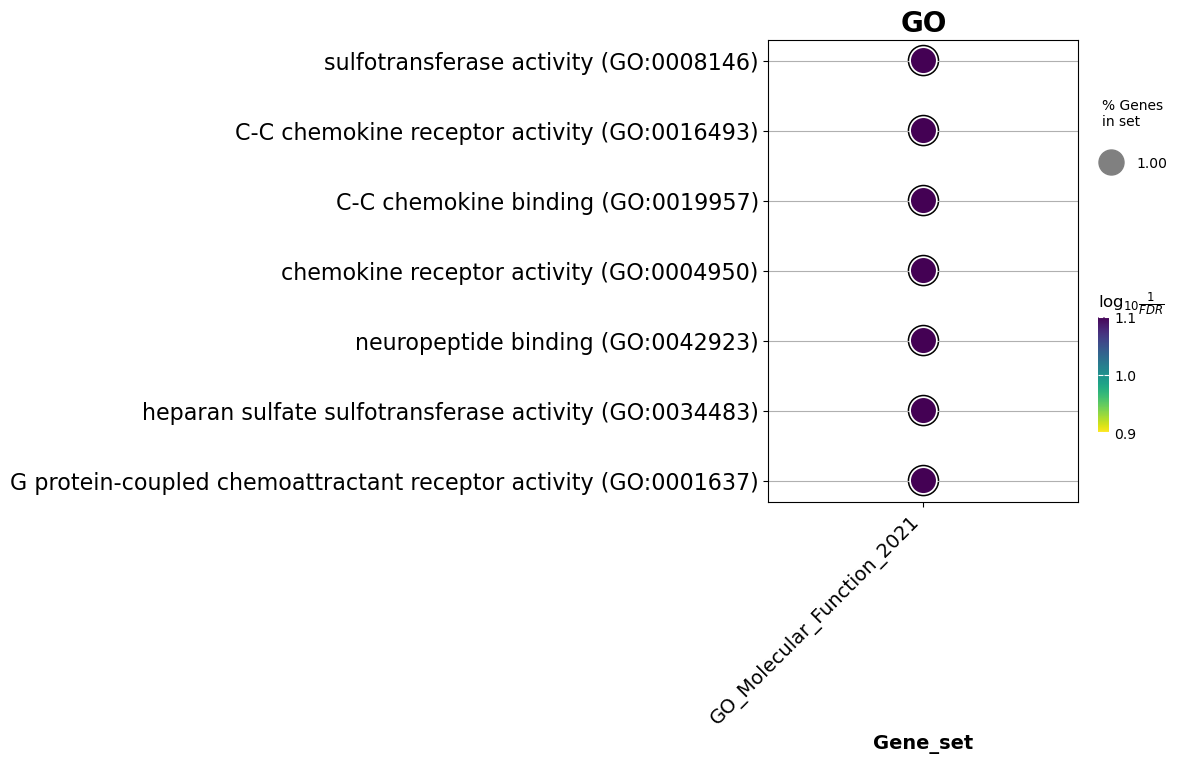

In [61]:
### UP in SZ
go_down = run_go(genes_down, genes_all )
get_dot_plot(go_down)

In [64]:
### in TAD borders that are UP in SZ
genes = []
for gene_list in [i.split(";") for i in go_down.results[go_down.results['Adjusted P-value'] <=0.05].Genes]:
    for gene in gene_list:
        genes.append(gene)
genes = list(set(genes))
genes

['CHST12', 'MCHR1', 'CCR5', 'SSTR4', 'CCRL2', 'NDST4', 'HS3ST3A1']

None of these are established, genome‑wide significant schizophrenia risk genes. A few have suggestive or population‑specific reports.

HS3ST3A1: Some candidate‑gene/association reports (and occasional CNV/rare‑variant findings) link it to schizophrenia in certain cohorts; not consistently replicated in large GWAS.
MCHR1: Occasional small‑study associations and rare CNVs reported; biologically plausible (brain‑expressed neuropeptide receptor), but not a robust GWAS hit.
SSTR4: Nominal associations and epigenetic/brain‑expression links; ties to somatostatin interneuron biology implicated in schizophrenia; not genome‑wide significant.
NDST4: Sporadic reports of rare variants/CNV involvement; evidence inconsistent and not supported by large GWAS.
Weaker/mostly negative to date:

CCR5 and CCRL2: Immune/chemokine receptors in a 3p21 region with nearby psychiatric signals, but common‑variant associations for these specific genes have not been robust; CCR5-Δ32 studies are largely null or mixed.
CHST12: Little direct genetic evidence; at most indirect biological plausibility via extracellular matrix/perineuronal net pathways.
If you need a pragmatic subset of “possibly connected” based on current literature: HS3ST3A1, MCHR1, SSTR4, and (more weakly) NDST4.

In [46]:
go_down.results[go_down.results['Adjusted P-value'] <=0.05].Term.tolist()

['G protein-coupled chemoattractant receptor activity (GO:0001637)',
 'heparan sulfate sulfotransferase activity (GO:0034483)',
 'neuropeptide binding (GO:0042923)',
 'chemokine receptor activity (GO:0004950)',
 'C-C chemokine binding (GO:0019957)',
 'C-C chemokine receptor activity (GO:0016493)',
 'sulfotransferase activity (GO:0008146)',
 'Glycosaminoglycan Synthesis In Fibroblasts WP5395']

Several of these processes have plausible links to schizophrenia, with varying strength of evidence.

Stronger/plausible links

Neuropeptide binding (GO:0042923): Consistent postmortem and transcriptomic evidence of altered neuropeptide signaling (e.g., somatostatin, NPY) and interneuron dysfunction in schizophrenia.
Chemokine/chemoattractant GPCR activity
Chemokine receptor activity (GO:0004950)
C-C chemokine receptor activity (GO:0016493)
C-C chemokine binding (GO:0019957)
G protein-coupled chemoattractant receptor activity (GO:0001637) Immune/chemokine dysregulation is repeatedly observed in schizophrenia (peripheral chemokine changes, microglial signaling); pathway-level signals appear in some genetic and expression studies, though specific receptor genes are not consistent GWAS hits.
Suggestive/indirect links

Heparan sulfate sulfotransferase activity (GO:0034483)
Glycosaminoglycan Synthesis In Fibroblasts (WP5395) Heparan/chondroitin sulfate and perineuronal net biology influence synapse formation and plasticity; alterations have been reported in schizophrenia cohorts, and some HS-modifying enzymes have candidate/rare-variant signals. Evidence is mixed compared with immune/neuropeptide pathways.
Too broad on its own

Sulfotransferase activity (GO:0008146): This umbrella term is nonspecific; only the subset modifying neural glycosaminoglycans (e.g., heparan/chondroitin sulfate) is relevant.